# Bitcoin forecasting API - tf_bitcoin.API.ipynb
Demonstration of core utility functions from `tf_bitcoin_utils.py`.

## Importing Libraries

In [1]:
from tf_bitcoin_utils import fetch_bitcoin_prices, plot_bitcoin_prices, fetch_bitcoin_prices_with_volatility
from tensorflow import convert_to_tensor
from keras.layers import TFSMLayer
import numpy as np
import matplotlib.pyplot as plt


## Fetch Raw Bitcoin Price Data

INFO:root:Trying CoinGecko API: https://api.coingecko.com/api/v3/coins/bitcoin/market_chart
INFO:root:Trying CoinCap API: https://api.coincap.io/v2/assets/bitcoin/history?interval=h1&start=1744935698325&end=1747527698325
INFO:root:Trying Binance API: https://api.binance.com/api/v3/klines
INFO:root:Got current price from Coinbase: $103183.675
c:\Users\raviv\OneDrive\Documents\Sem2 Assignments\Big Data Project\bitcoin605\DATA605\Spring2025\projects\TutorTask162_Spring2025_Real-Time_Bitcoin_Data_Processing_using_TensorFlow_Extended\tutorial_template\tfx_pipeline\tf_bitcoin_utils.py:219: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start=start_date, end=end_date, freq='H')
c:\Users\raviv\OneDrive\Documents\Sem2 Assignments\Big Data Project\bitcoin605\DATA605\Spring2025\projects\TutorTask162_Spring2025_Real-Time_Bitcoin_Data_Processing_using_TensorFlow_Extended\tutorial_template\tfx_pipeline\tf_bitcoin_utils.py:265

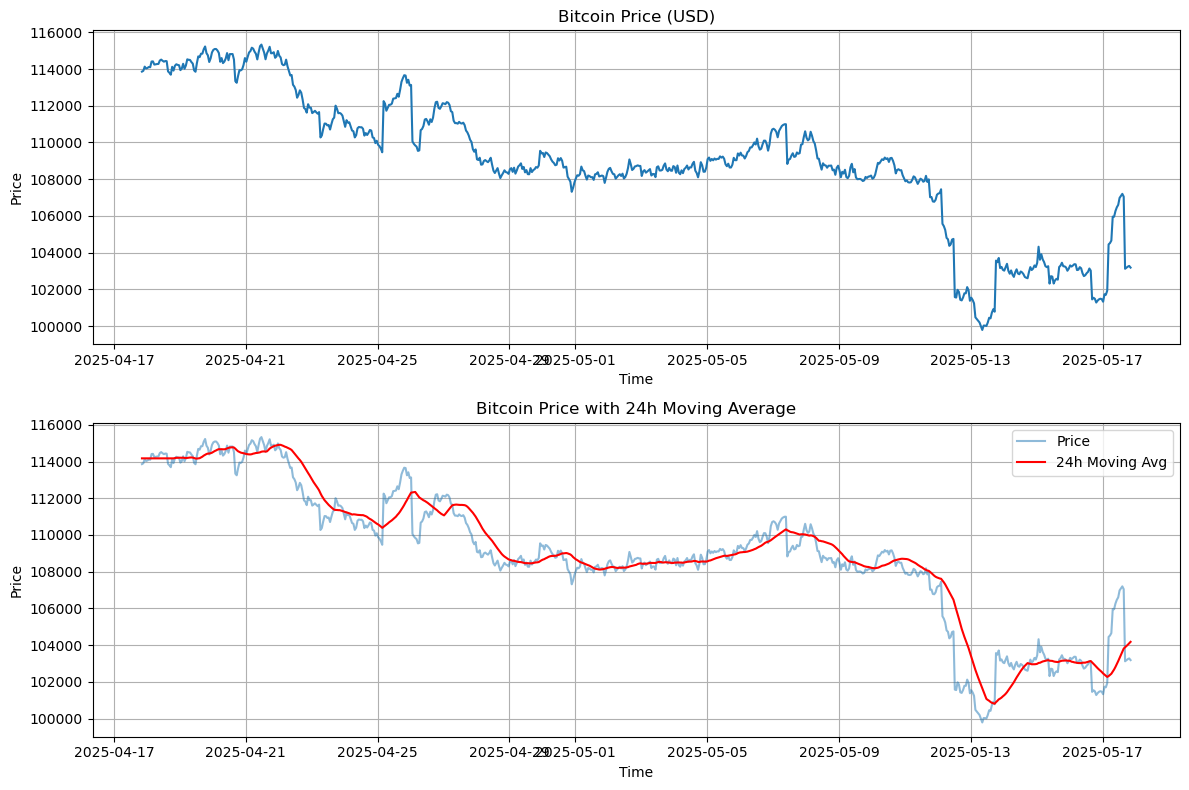

In [3]:

df = fetch_bitcoin_prices_with_volatility(days=30)
plot_bitcoin_prices(df).show()


## Preparing Import Data

In [4]:

X = df["price"].values[-24:]
input_seq = convert_to_tensor(X.reshape(1, -1, 1), dtype='float32')


## Sending to model to predict

✓ Loaded forecast data: 168 records

📊 Forecast Analysis:
   Initial Price: $103,417.63
   Final Price: $146,380.53
   Total Change: +41.54%
   Max Price: $146,454.55
   Min Price: $103,417.63
   Average Price: $124,898.00

🎯 Key Predictions:
    24-Hour: $112,649.97 (↑  8.93%)
      3-Day: $125,104.26 (↑ 20.97%)
      7-Day: $146,380.53 (↑ 41.54%)


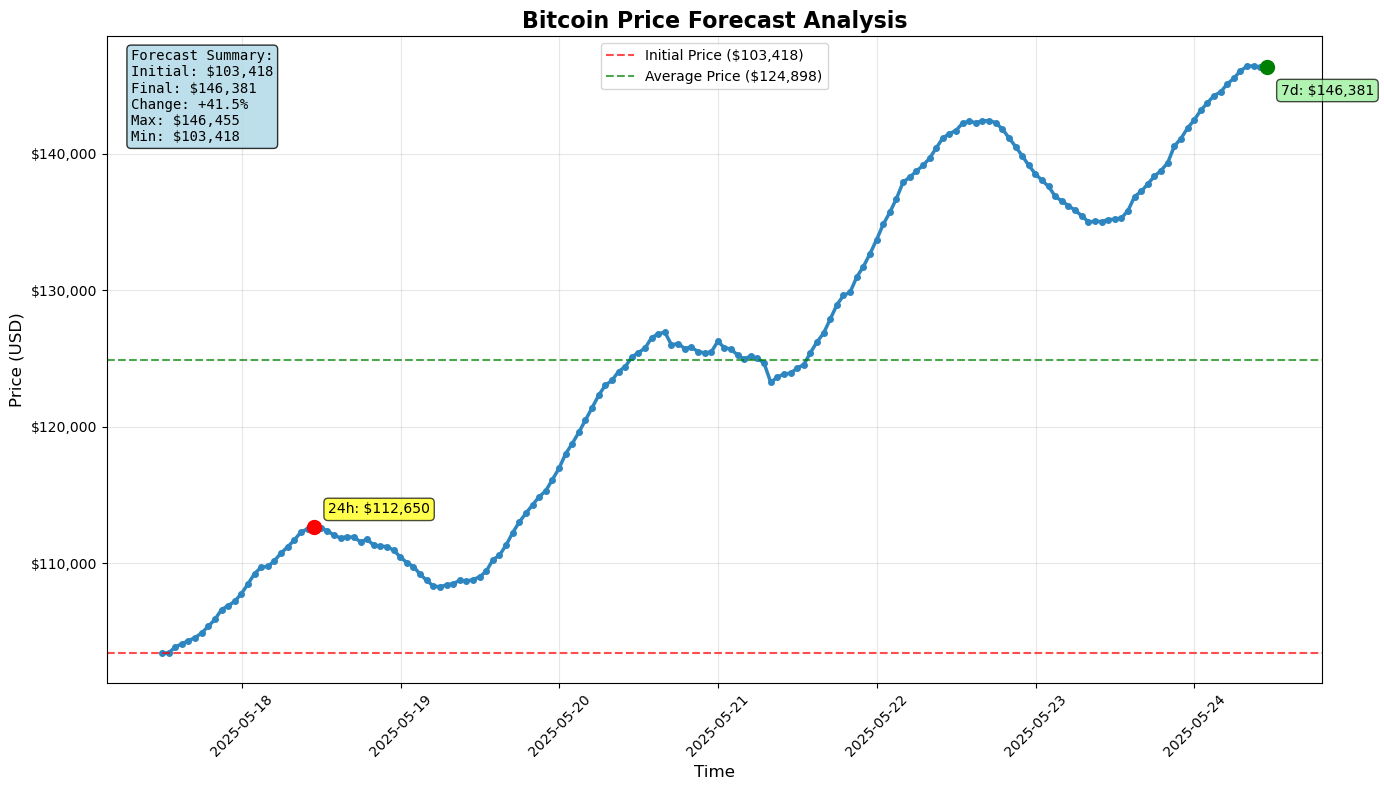


Quick Summary:
Total Change: +41.54%
Final Price: $146,380.53


In [6]:
from predict import analyze_existing_forecast

forecast_file = r"C:\Users\raviv\OneDrive\Documents\Sem2 Assignments\Big Data Project\bitcoin605\DATA605\Spring2025\projects\TutorTask162_Spring2025_Real-Time_Bitcoin_Data_Processing_using_TensorFlow_Extended\tutorial_template\tfx_pipeline\forecasts\bitcoin_forecast_20250517_1056.csv"

results = analyze_existing_forecast(forecast_file)

if results:
    print(f"\nQuick Summary:")
    print(f"Total Change: {results['total_change']:+.2f}%")
    print(f"Final Price: ${results['final_price']:,.2f}")